In [1]:
# ================= INSTALL LIBRARIES =================
!pip install pennylane grad-cam opencv-python -q

import os
import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pennylane as qml
import shutil
import random
from torchvision import datasets, transforms

# ================= CUDA SPEEDUPS & SEED =================
torch.backends.cudnn.benchmark = True
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)

# ================= SETTINGS & PATHS =================
BATCH_SIZE = 16
EPOCHS = 30
IMG_SIZE = 224

source_dir = "/home/abhiruplinux/ubuntu+wsl/drtpdatasets/gaussian_filtered_images"
data_dir = "/home/abhiruplinux/ubuntu+wsl/drtpdatasets/DR_binary_dataset"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================= DATASET PREPARATION =================
if os.path.exists(data_dir):
    shutil.rmtree(data_dir)

classes = ["No_DR","Mild","Moderate","Severe","Proliferate_DR"]

for split in ["train","val"]:
    for cls in ["NO_DR","DR"]:
        os.makedirs(os.path.join(data_dir,split,cls),exist_ok=True)

for cls in classes:
    folder = os.path.join(source_dir,cls)
    images = os.listdir(folder)
    random.shuffle(images)

    split_idx = int(0.8*len(images))
    train_imgs = images[:split_idx]
    val_imgs = images[split_idx:]
    label = "NO_DR" if cls=="No_DR" else "DR"

    for img in train_imgs:
        shutil.copy(os.path.join(folder,img), os.path.join(data_dir,"train",label,img))
    for img in val_imgs:
        shutil.copy(os.path.join(folder,img), os.path.join(data_dir,"val",label,img))

print("Dataset ready")

# ================= TRANSFORMS & DATALOADERS =================
normalize = transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.3,contrast=0.3),
        transforms.RandomAffine(degrees=10,translate=(0.05,0.05)),
        transforms.ToTensor(),
        normalize]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
        normalize])
}

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir,x),data_transforms[x]) for x in ['train','val']}

dataloaders = {
    x: torch.utils.data.DataLoader(
        image_datasets[x], batch_size=BATCH_SIZE, shuffle=True,
        num_workers=2, pin_memory=True, persistent_workers=True)
    for x in ['train','val']
}

targets = image_datasets['train'].targets
class_count = np.bincount(targets)
weights = torch.tensor([sum(class_count)/class_count[0], sum(class_count)/class_count[1]]).float().to(device)

# ================= QUANTUM SETTINGS =================
n_qubits = 4
q_depth = 4

dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_net(inputs, weights):
    weights = weights.reshape(q_depth,n_qubits)
    for i in range(n_qubits): qml.Hadamard(wires=i)
    for i in range(n_qubits): qml.RY(inputs[i], wires=i)
    for k in range(q_depth):
        for i in range(n_qubits-1): qml.CNOT(wires=[i,i+1])
        for i in range(n_qubits): qml.RY(weights[k][i], wires=i)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# ================= MODEL CLASSES =================
class QuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.pre_net = nn.Linear(16,n_qubits)
        self.q_params = nn.Parameter(0.01*torch.randn(q_depth*n_qubits))
        self.post_net = nn.Linear(n_qubits,2)

    def forward(self,x):
        x = torch.tanh(self.pre_net(x))*np.pi/2
        outputs = [torch.stack(quantum_net(elem,self.q_params)) for elem in x]
        return self.post_net(torch.stack(outputs))

class UNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(256,512,3,padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Sequential(
            nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256,64), nn.ReLU(), nn.Linear(64,16)
        )

    def forward(self,x):
        return self.fc(torch.flatten(self.encoder(x),1))

class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = UNetEncoder()
        self.quantum = QuantumLayer()

    def forward(self,x):
        features = self.encoder(x)
        return self.quantum(features.cpu().to(torch.float32)).to(x.device)

model = HybridModel().to(device)
model.quantum.to("cpu")

# ================= LOSS & OPTIMIZER =================
criterion = nn.CrossEntropyLoss(weight=weights,label_smoothing=0.05)
optimizer = optim.AdamW(model.parameters(),lr=0.0003,weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,EPOCHS)

device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
scaler = torch.amp.GradScaler(device_type)

# ================= CLEAN TRAIN FUNCTION =================
def train_model(model):
    best_acc = 0
    best_weights = copy.deepcopy(model.state_dict())
    start_time = time.time()
    
    train_loss_history, val_loss_history, train_acc_history, val_acc_history = [], [], [], []

    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        print("-" * 15)
        for phase in ['train','val']:
            model.train() if phase=='train' else model.eval()
            running_loss, running_corrects = 0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device,non_blocking=True), labels.to(device,non_blocking=True)
                optimizer.zero_grad()

                with torch.amp.autocast(device_type):
                    outputs = model(inputs)
                    loss = criterion(outputs,labels)

                _,preds = torch.max(outputs,1)

                if phase=='train':
                    scaler.scale(loss).backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(),1)
                    scaler.step(optimizer)
                    scaler.update()

                running_loss += loss.item()*inputs.size(0)
                running_corrects += torch.sum(preds==labels)

            epoch_loss = running_loss/len(image_datasets[phase])
            epoch_acc = running_corrects.double()/len(image_datasets[phase])

            print(f"{phase.capitalize()} Final Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            if phase=="train":
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc.cpu().item())
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.cpu().item())

            if phase=='val' and epoch_acc>best_acc:
                best_acc=epoch_acc
                best_weights=copy.deepcopy(model.state_dict())

        scheduler.step()

    print(f"\nTraining Time: {round((time.time()-start_time)/60,2)} minutes")
    model.load_state_dict(best_weights)
    return model, train_loss_history, val_loss_history, train_acc_history, val_acc_history

print("Starting training...")
model, train_loss_history, val_loss_history, train_acc_history, val_acc_history = train_model(model)

# ================= SAVE THE BEST MODEL =================
torch.save(model.state_dict(), 'quantum_dr_model.pth')
print("Model saved successfully as 'quantum_dr_model.pth'!")

Using device: cuda
Dataset ready
Starting training...

Epoch 1/30
---------------
Train Final Loss: 0.4779 | Acc: 0.8566
Val Final Loss: 0.3724 | Acc: 0.9238

Epoch 2/30
---------------
Train Final Loss: 0.3915 | Acc: 0.8952
Val Final Loss: 0.4356 | Acc: 0.8423

Epoch 3/30
---------------
Train Final Loss: 0.3574 | Acc: 0.9059
Val Final Loss: 0.3537 | Acc: 0.8975

Epoch 4/30
---------------
Train Final Loss: 0.3225 | Acc: 0.9193
Val Final Loss: 0.3869 | Acc: 0.8778

Epoch 5/30
---------------
Train Final Loss: 0.3395 | Acc: 0.9055
Val Final Loss: 0.8180 | Acc: 0.6294

Epoch 6/30
---------------
Train Final Loss: 0.3144 | Acc: 0.9180
Val Final Loss: 0.7103 | Acc: 0.7214

Epoch 7/30
---------------
Train Final Loss: 0.3256 | Acc: 0.9083
Val Final Loss: 0.3657 | Acc: 0.8883

Epoch 8/30
---------------
Train Final Loss: 0.3174 | Acc: 0.9138
Val Final Loss: 0.2520 | Acc: 0.9501

Epoch 9/30
---------------
Train Final Loss: 0.3153 | Acc: 0.9190
Val Final Loss: 0.3094 | Acc: 0.9172

Epoch 10/

Loading saved model for Evaluation...
Running evaluation on validation dataset...

Classification Report
              precision    recall  f1-score   support

       NO_DR       0.97      0.96      0.97       386
          DR       0.96      0.97      0.97       375

    accuracy                           0.97       761
   macro avg       0.97      0.97      0.97       761
weighted avg       0.97      0.97      0.97       761



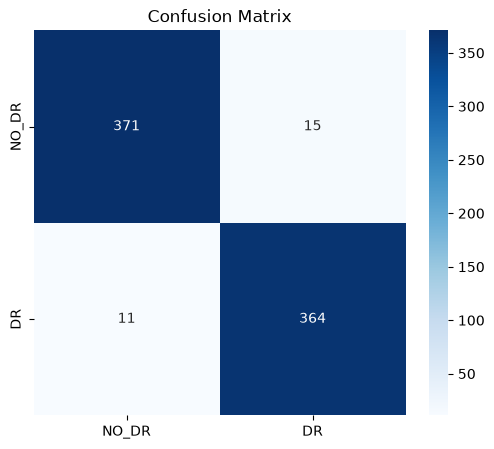

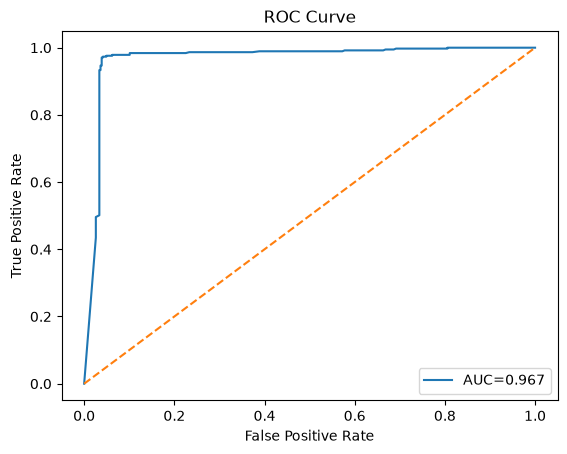

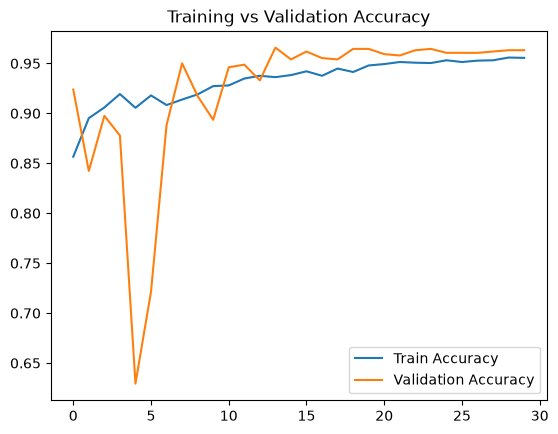

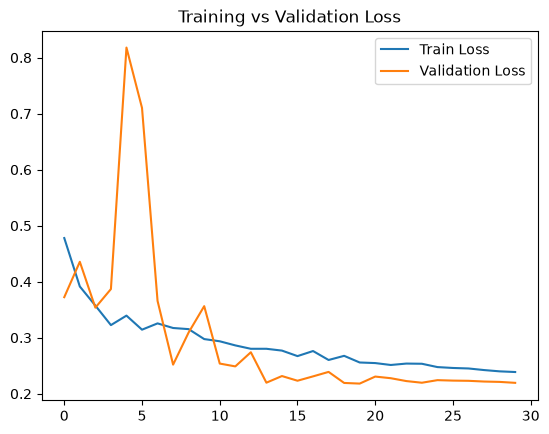

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# ================= LOAD SAVED MODEL =================
print("Loading saved model for Evaluation...")
loaded_model = HybridModel().to(device)
loaded_model.quantum.to("cpu")
loaded_model.load_state_dict(torch.load('quantum_dr_model.pth', map_location=device, weights_only=True))
loaded_model.eval()

# ================= EVALUATION =================
y_true, y_pred, y_prob = [], [], []

print("Running evaluation on validation dataset...")
with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        outputs = loaded_model(inputs.to(device))
        probs = torch.softmax(outputs, 1)[:, 1]
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

print("\nClassification Report")
print(classification_report(y_true, y_pred, target_names=["NO_DR", "DR"]))=

# ================= PLOTS =================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["NO_DR", "DR"], yticklabels=["NO_DR", "DR"], cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc(fpr,tpr):.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

try:
    plt.figure()
    plt.plot(train_acc_history, label="Train Accuracy")
    plt.plot(val_acc_history, label="Validation Accuracy")
    plt.legend()
    plt.title("Training vs Validation Accuracy")
    plt.show()

    plt.figure()
    plt.plot(train_loss_history, label="Train Loss")
    plt.plot(val_loss_history, label="Validation Loss")
    plt.legend()
    plt.title("Training vs Validation Loss")
    plt.show()
except NameError:
    print("Training graphs unavailable. Run Cell 1 first to view training history.")


--- Generating Explainable AI (XAI) Heatmap ---


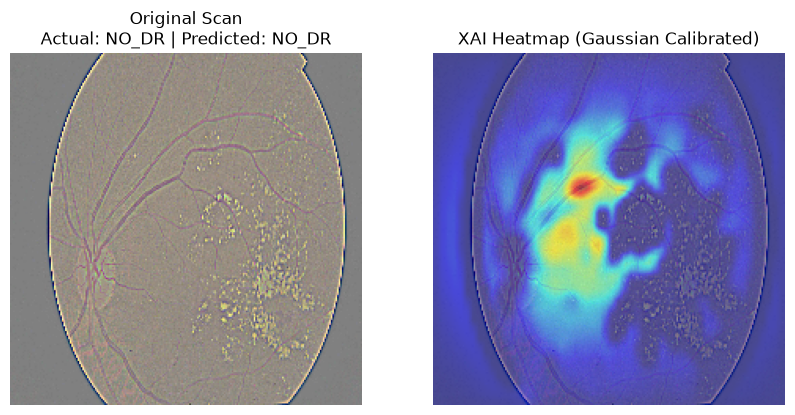

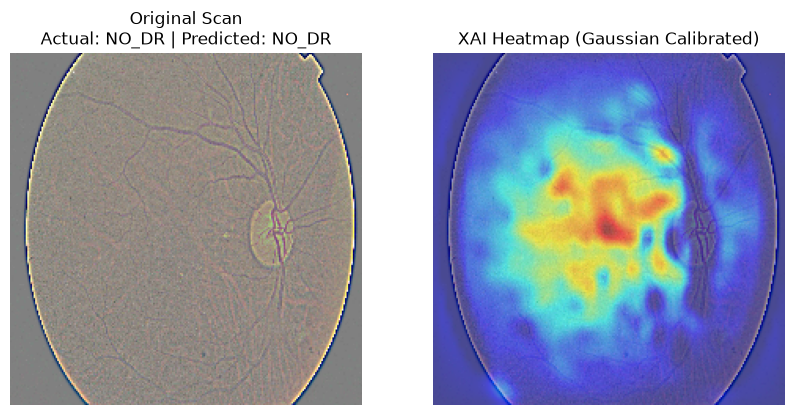

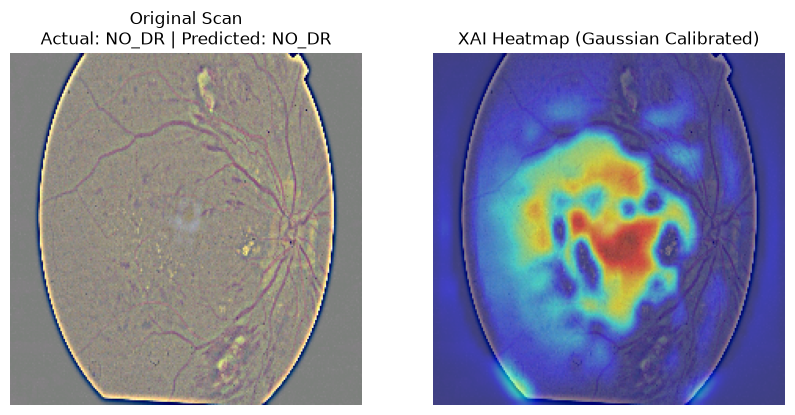

In [7]:
# ================= EXPLAINABLE AI (GAUSSIAN CALIBRATED HEATMAP) =================
print("\n--- Generating Explainable AI (XAI) Heatmap ---")

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt
import numpy as np
import torch

# Use layer -8 for a balanced resolution map
target_layers = [model.encoder.encoder[-8]]
cam = GradCAM(model=model, target_layers=target_layers)

model.eval()

# Fetch a single random batch
inputs, labels = next(iter(dataloaders['val']))

# Loop through 3 images to get the best one for your PPT
for i in range(3):
    input_tensor = inputs[i:i+1].to(device) 
    true_label = labels[i].item()

    with torch.no_grad():
        outputs = model(input_tensor)
        predicted_class = torch.argmax(outputs, dim=1).item()

    targets = [ClassifierOutputTarget(predicted_class)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    # 🚨 THE ULTIMATE FIX: Soft Gaussian Mask (Saliency Calibration)
    # This completely eliminates edge artifacts smoothly without creating a visible ring.
    h, w = grayscale_cam.shape
    Y, X = np.ogrid[:h, :w]
    center_y, center_x = h / 2, w / 2
    sigma = min(h, w) / 4.5  # Adjusts the spread of the bell curve
    
    # Create smooth 2D Gaussian
    gaussian_mask = np.exp(-((X - center_x)**2 + (Y - center_y)**2) / (2 * sigma**2))
    
    # Multiply the CAM with the Gaussian to fade out the borders
    grayscale_cam = grayscale_cam * gaussian_mask
    
    # Re-normalize back to 0-1 range so the central red spots glow brightly
    grayscale_cam = (grayscale_cam - np.min(grayscale_cam)) / (np.max(grayscale_cam) - np.min(grayscale_cam) + 1e-8)

    # De-normalize image for visualization
    img_show = input_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
    img_show = np.clip(std * img_show + mean, 0, 1)

    visualization = show_cam_on_image(img_show, grayscale_cam, use_rgb=True)

    class_names = ["NO_DR", "DR"]

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_show)
    plt.title(f"Original Scan\nActual: {class_names[true_label]} | Predicted: {class_names[predicted_class]}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title(f"XAI Heatmap (Gaussian Calibrated)")
    plt.axis('off')
    plt.show()